# Mutual Fund Analytics - Exploratory Data Analysis

## Objective

#This notebook analyzes mutual fund industry data including:

- NAV trends
- AUM growth
- SIP inflows
- Category-wise fund inflows
- Investor demographics
- Geographic distribution
- Folio growth
- Fund correlations
- Sector allocation

The goal is to identify investment trends, investor behavior, and fund performance patterns.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# 1. SIP Inflow Analysis

This section analyzes monthly SIP inflows from 2022–2025 to understand retail investor participation and industry growth.

In [5]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


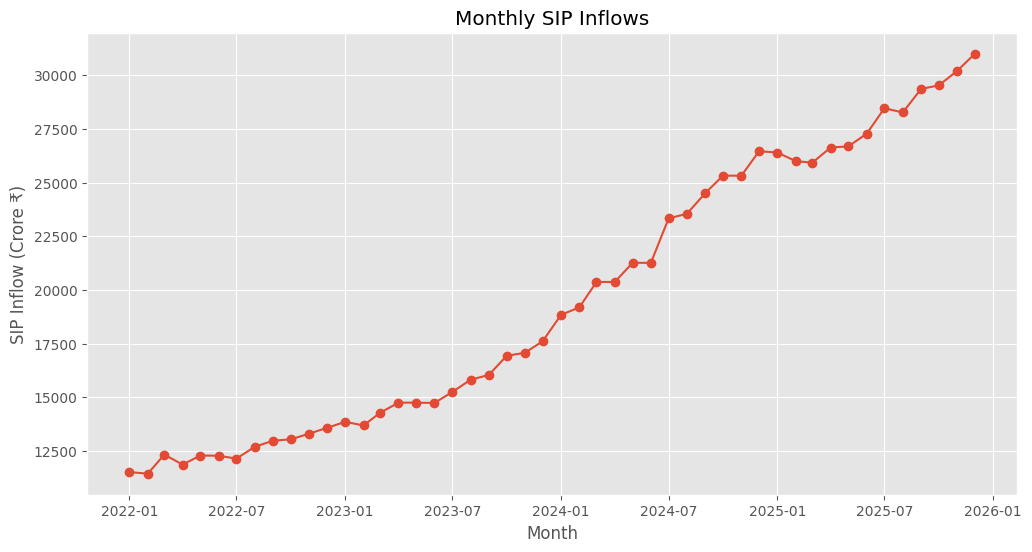

In [6]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.show()

### Insight

SIP inflows increased consistently from 2022 to 2025, indicating growing retail participation and rising investor confidence in mutual funds.

# 2. AUM Growth Analysis

This section analyzes Assets Under Management (AUM) across major fund houses to understand market leadership and growth trends.

In [7]:
aum = pd.read_csv(
    "data/raw/03_aum_by_fund_house.csv"
)

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


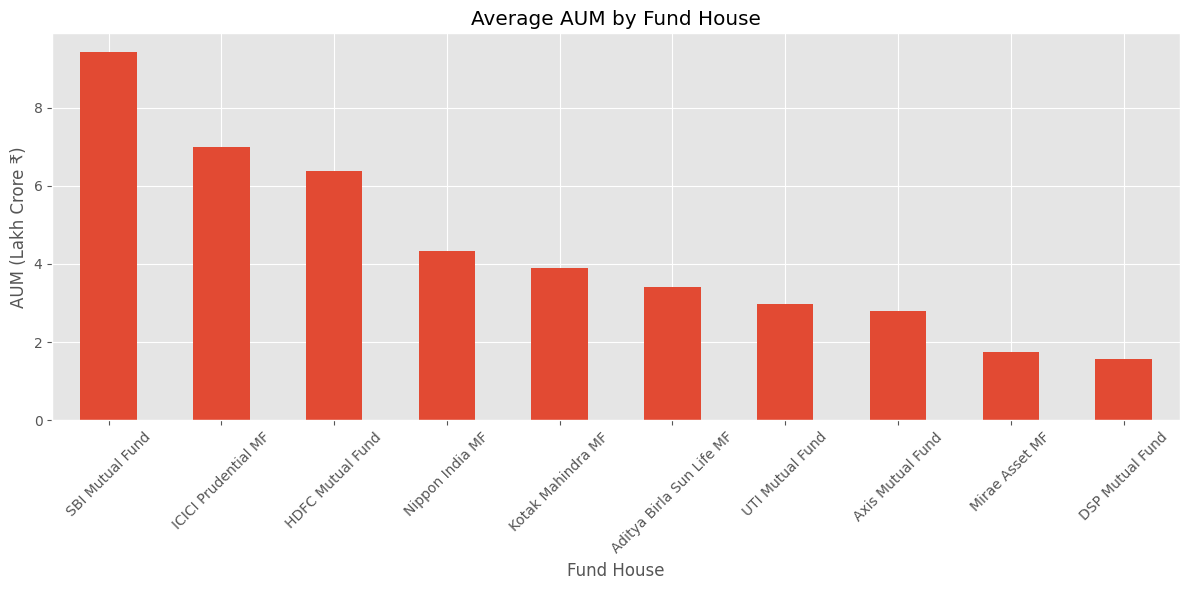

In [8]:
plt.figure(figsize=(12,6))

top_aum = (
    aum.groupby("fund_house")["aum_lakh_crore"]
    .mean()
    .sort_values(ascending=False)
)

top_aum.plot(kind="bar")

plt.title("Average AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Insight

SBI Mutual Fund maintains one of the largest AUM bases among all fund houses, indicating strong market presence and investor trust.

# 3. Category Inflow Analysis

This section analyzes category-wise mutual fund inflows to identify which categories attract the highest investor interest.

In [9]:
category = pd.read_csv(
    "data/raw/05_category_inflows.csv"
)

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


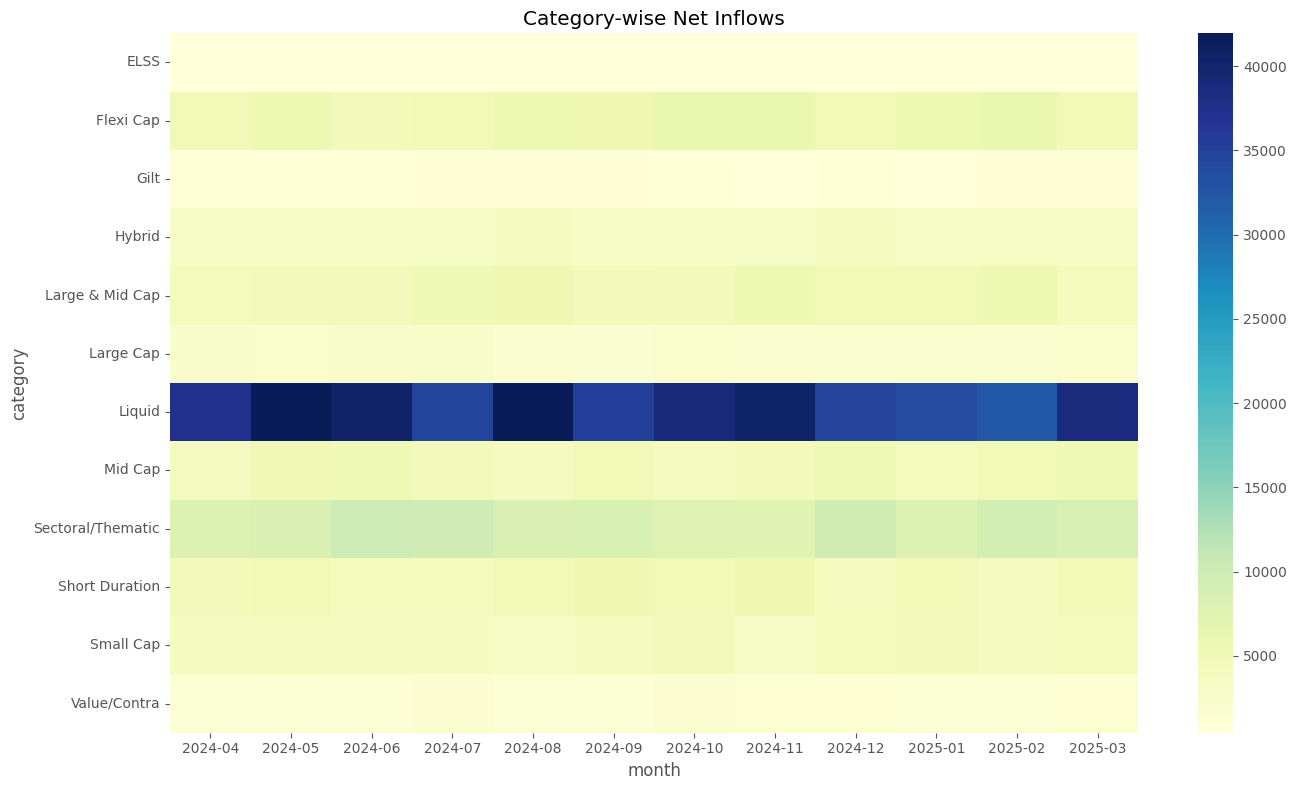

In [11]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows")

plt.tight_layout()

plt.show()

### Insight

Equity-oriented categories such as Large Cap, Mid Cap, Small Cap, and Flexi Cap consistently attracted strong inflows, reflecting investor preference for growth-oriented investments.

# 4. Investor Demographics

This section examines investor age groups, gender participation, and investment behavior.

In [12]:
investors = pd.read_csv(
    "data/raw/08_investor_transactions.csv"
)

investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


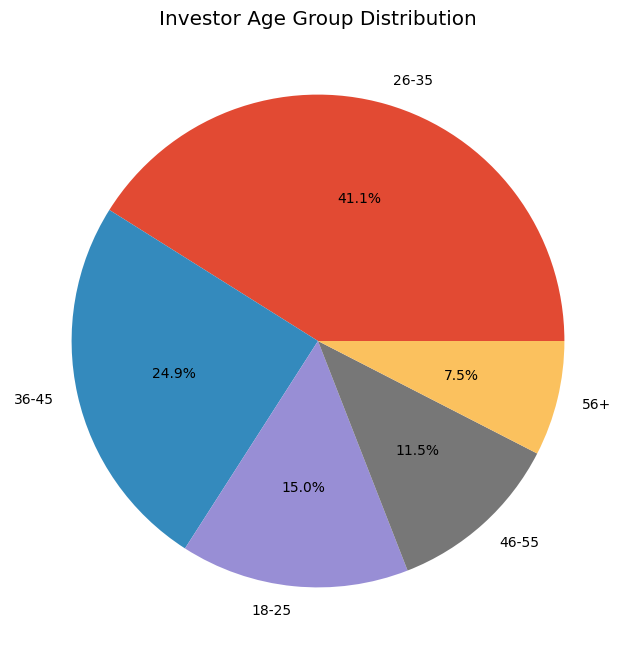

In [13]:
age_counts = investors["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

### Insight

Most investors belong to the 26–35 and 36–45 age groups, indicating strong participation from working professionals.

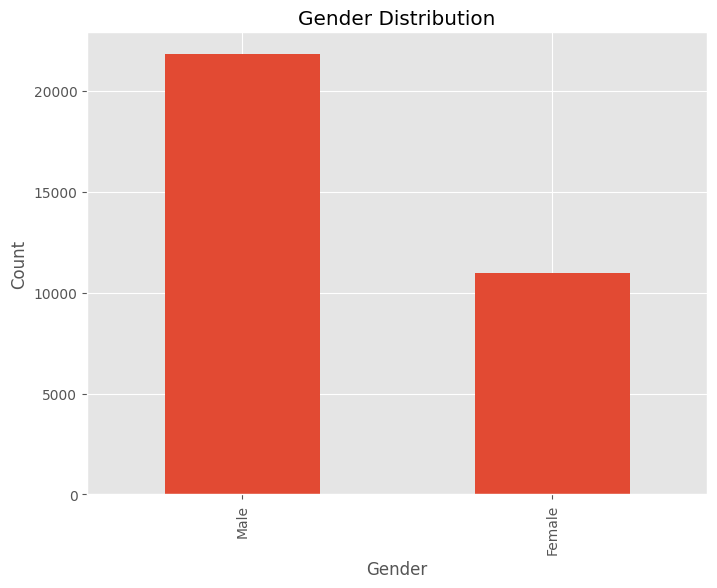

In [14]:
gender_counts = investors["gender"].value_counts()

plt.figure(figsize=(8,6))

gender_counts.plot(kind="bar")

plt.title("Gender Distribution")

plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Insight

Most investors belong to the 26–35 and 36–45 age groups, indicating strong participation from working professionals.

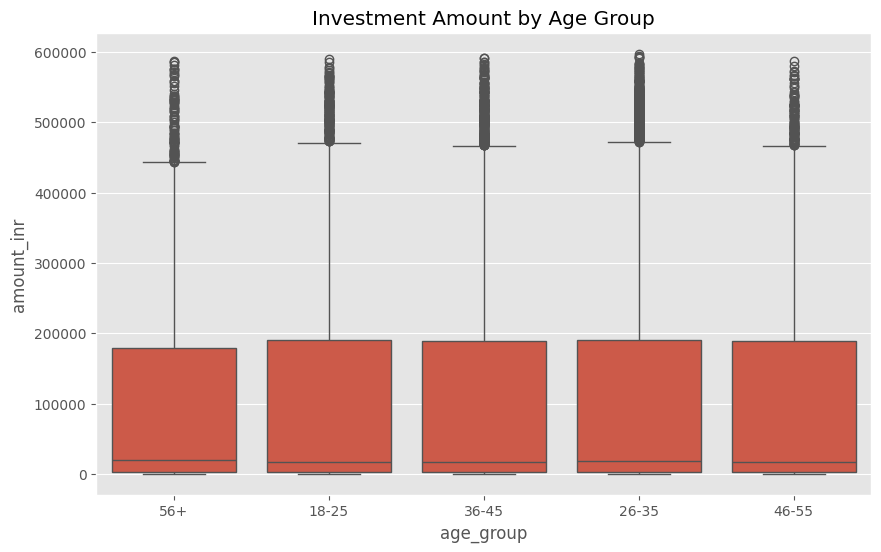

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="age_group",
    y="amount_inr",
    data=investors
)

plt.title("Investment Amount by Age Group")

plt.show()

### Insight

Investment amounts vary across age groups, with several high-value transactions visible as outliers.

# 5. Geographic Distribution

This section analyzes mutual fund investment activity across states and city tiers.

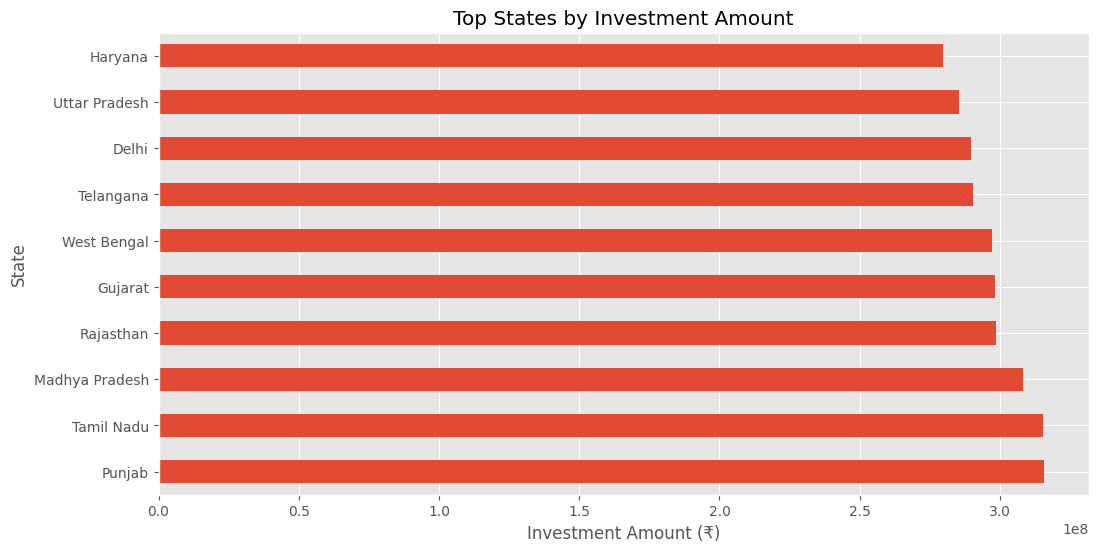

In [17]:
state_sip = (
    investors.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_sip.plot(kind="barh")

plt.title("Top States by Investment Amount")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.show()

### Insight

A few large states contribute a significant share of total investment activity, highlighting regional concentration in mutual fund participation.

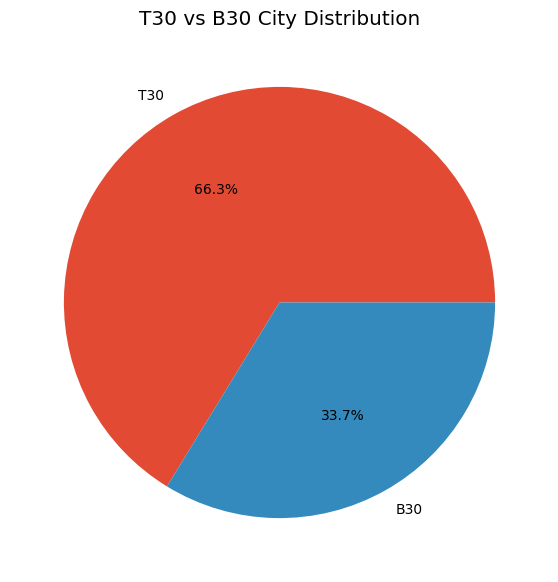

In [18]:
tier_counts = investors["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Distribution")

plt.show()

### Insight

Both T30 and B30 cities contribute meaningfully to investments, showing mutual fund adoption beyond major metropolitan areas.

In [19]:
investors.groupby("city_tier")["amount_inr"].sum()

city_tier
B30    1202325640
T30    2319254790
Name: amount_inr, dtype: int64

# 6. Folio Count Growth

This section analyzes the growth in mutual fund folios from 2022 to 2025, reflecting increasing investor participation.

In [21]:
folios = pd.read_csv(
    "data/raw/06_industry_folio_count.csv"
)

folios.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


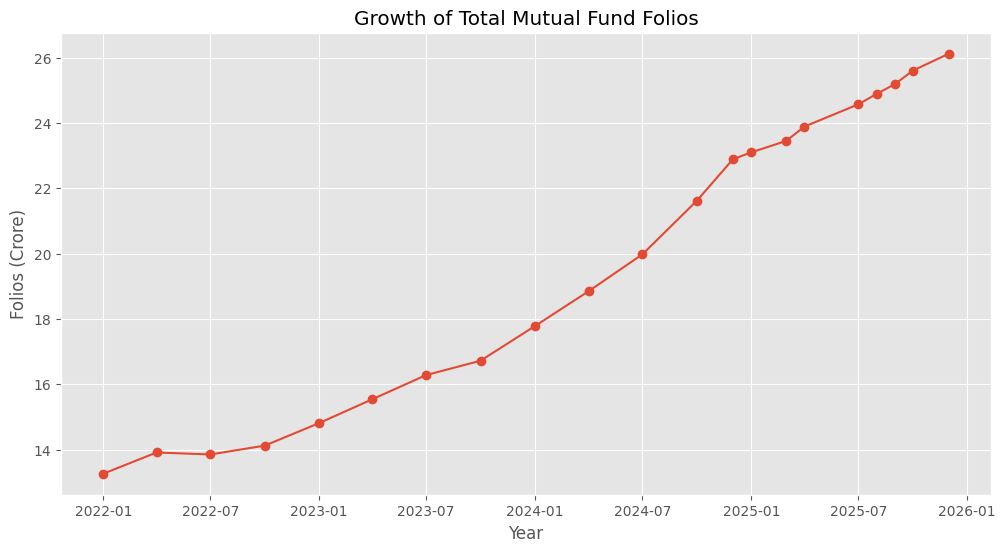

In [22]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Growth of Total Mutual Fund Folios")

plt.xlabel("Year")

plt.ylabel("Folios (Crore)")

plt.show()

### Insight

Total folio count increased steadily throughout the period, indicating rising participation from retail investors and growing awareness of mutual funds.

# 7. NAV Trend Analysis

This section studies NAV movement across mutual fund schemes over time.

In [23]:
nav = pd.read_csv(
    "data/raw/02_nav_history.csv"
)

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [24]:
nav["date"] = pd.to_datetime(nav["date"])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


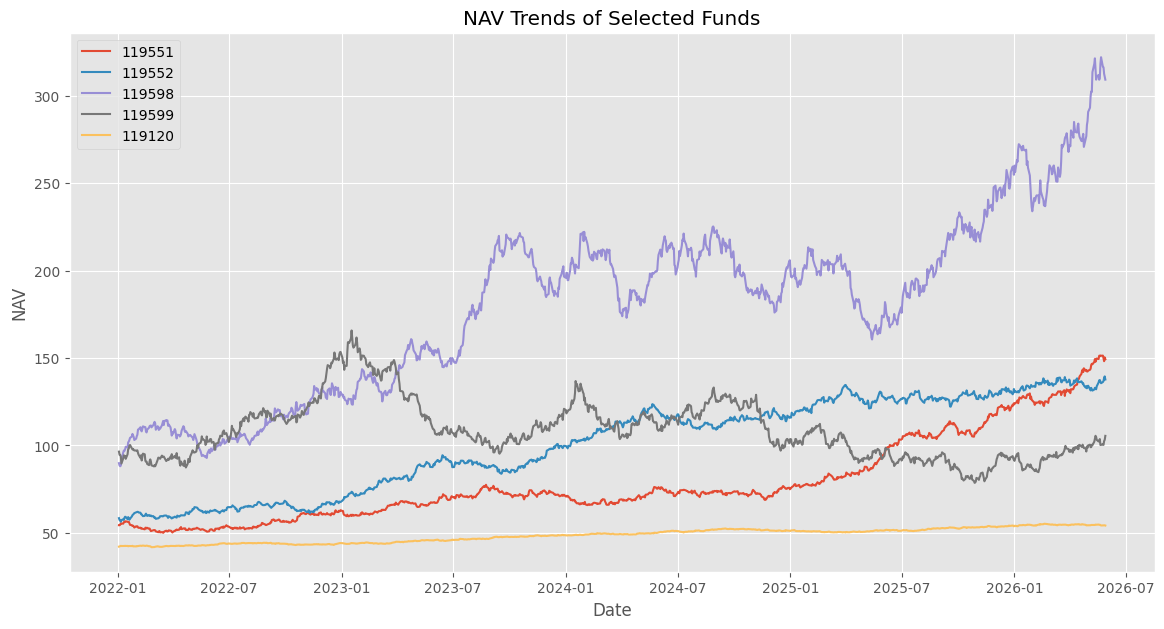

In [25]:
sample_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(14,7))

for fund in sample_funds:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.title("NAV Trends of Selected Funds")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.show()

### Insight

Most schemes exhibit a long-term upward NAV trend despite short-term market fluctuations, reflecting wealth creation potential over time.

# 8. NAV Return Correlation Matrix

This section measures how selected mutual fund schemes move relative to one another.

In [27]:
nav_returns = nav.copy()

nav_returns["daily_return"] = (
    nav_returns
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [28]:
pivot_returns = nav_returns.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

corr_matrix = pivot_returns.iloc[:, :10].corr()

corr_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384


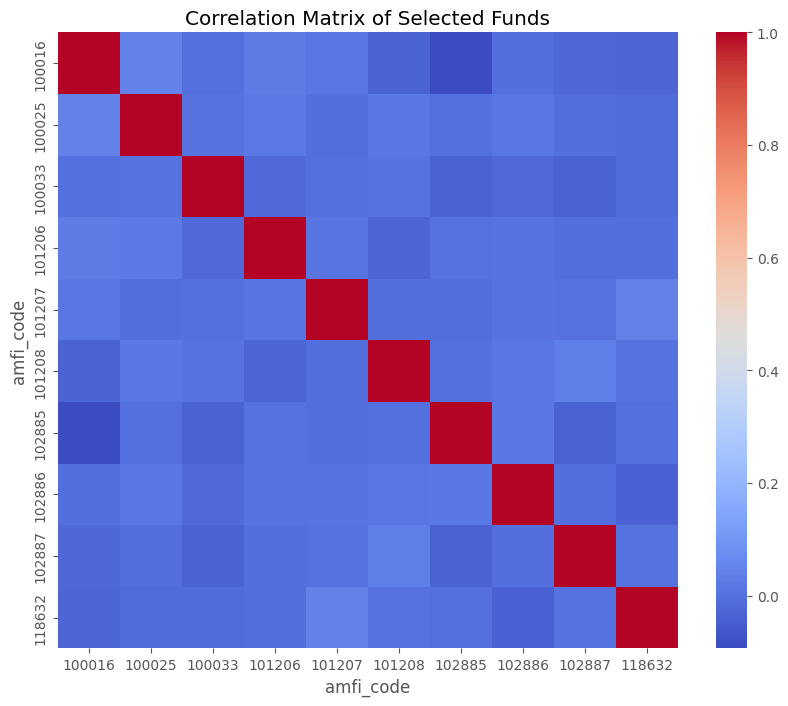

In [29]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix of Selected Funds")

plt.show()

### Insight

Many equity-oriented funds show positive correlation, indicating that they respond similarly to broader market movements.

# 9. Sector Allocation Analysis

This section examines portfolio exposure across different sectors.

In [30]:
holdings = pd.read_csv(
    "data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [31]:
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

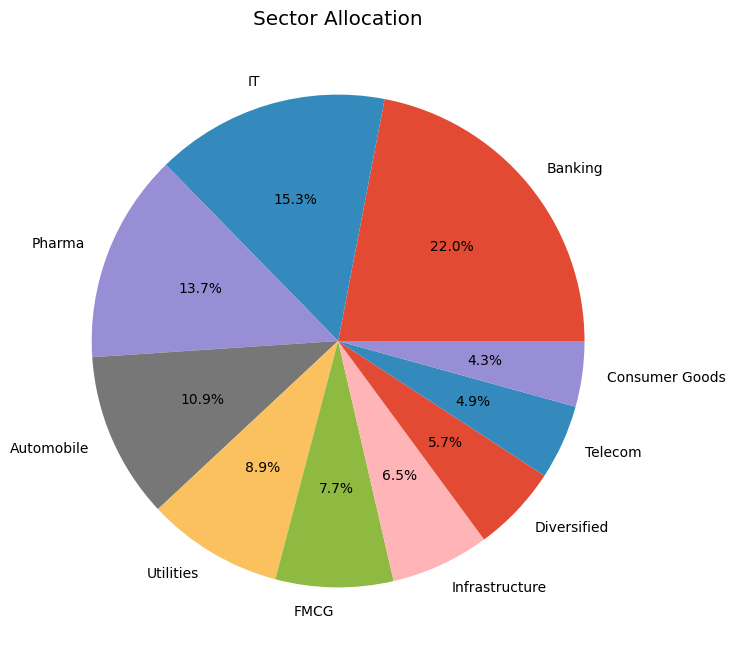

In [32]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_weights.head(10),
    labels=sector_weights.head(10).index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")

plt.show()

### Insight

Financial Services, Technology, Healthcare, and Consumer sectors account for a significant share of portfolio allocations.

# 10. Key Findings

1. SIP inflows increased steadily from 2022 to 2025.
2. SBI Mutual Fund maintains one of the largest AUM bases.
3. Equity-oriented categories attracted the highest inflows.
4. Working-age investors dominate mutual fund participation.
5. Mutual fund investments are concentrated in a few large states.
6. T30 and B30 cities both contribute significantly to investment activity.
7. Total folio counts have grown consistently over time.
8. NAV values generally exhibit long-term upward trends.
9. Many funds show positive correlation due to common market exposure.
10. Financial Services remains the largest sector allocation.